# 03 - Backtest: Regime-Based Allocation for a Euro Investor

**Question:** if an investor had followed the regime model in real time, with publication lags and trading costs, would they have done better than a static portfolio?

**Inputs:** `data/returns_eur.csv`, `data/returns_usd.csv`, `data/regimes.csv`, `data/macro_data.csv` (first version of the model)
**Output:** `data/regime_weights.csv` (portfolio weights by regime, used in `04_current_regime`)
**Period:** 2006 – September 2026 (monthly)

## 1. Design

**Investor:** euro-based, using euro returns and Euro area regimes.

**Avoiding look-ahead bias:**
- **Publication lags.** A regime can only be used once all its data has been published. For the Euro area, the Economic Sentiment Indicator and Eurostat's flash inflation estimate are both published at the end of the month they describe, so the September regime is known by early October and can first be used for October returns: a **1-month lag**. Strictly, the flash inflation estimate is released around the turn of the month, so trading at the month-end close can assume the figure a day or two early. With a 2-month lag, which removes any doubt about timing, the result is almost unchanged (Section 5). For the US, CPI and industrial production are published around mid-month, so the lag is **2 months**.
- **Tilts set in advance.** The regime tilts are based on economic reasoning, not on the results of `02_asset_returns`. Choosing tilts from the same data used to test them would make the backtest look better than it could have been in reality.

**Trading costs:** 0.1% of every euro traded. Portfolios are rebalanced monthly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({"font.size": 11})
Path("../figures").mkdir(exist_ok=True)

returns_eur = pd.read_csv("../data/returns_eur.csv", index_col=0, parse_dates=True)
returns_usd = pd.read_csv("../data/returns_usd.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv("../data/regimes.csv", index_col=0, parse_dates=True)
macro = pd.read_csv("../data/macro_data.csv", index_col=0, parse_dates=True)

LAG_EA = 1
LAG_US = 2

signal_ea = regimes["ea_regime"].shift(LAG_EA, freq="MS")
signal_us = regimes["us_regime"].shift(LAG_US, freq="MS")

pd.DataFrame({"ea_regime": regimes["ea_regime"], "signal_ea": signal_ea}).loc["2020-01":"2020-08"]

,ea_regime,signal_ea
2020-01-01,Overheating,Stagflation
2020-02-01,Overheating,Overheating
2020-03-01,Slowdown,Overheating
2020-04-01,Slowdown,Slowdown
2020-05-01,Slowdown,Slowdown
2020-06-01,Slowdown,Slowdown
2020-07-01,Slowdown,Slowdown
2020-08-01,Slowdown,Slowdown


## 2. Portfolio weights

The strategy starts from a neutral portfolio and tilts it according to the regime.

| Asset | Neutral | Goldilocks | Overheating | Slowdown | Stagflation |
|---|---|---|---|---|---|
| SPY (US equities) | 25 | +10 | +5 | −5 | −10 |
| VGK (European equities) | 20 | +10 | +5 | −10 | −10 |
| TLT (long Treasuries) | 20 | | −10 | +10 | −5 |
| LQD (IG credit) | 10 | | −10 | | |
| SHY (short Treasuries) | 10 | −10 | | +5 | +10 |
| GLD (gold) | 10 | −10 | | +5 | +10 |
| DBC (commodities) | 5 | | +10 | −5 | +5 |

**Reasoning:**
- **Goldilocks:** profits grow and rates stay low → more equities, less protection (cash, gold).
- **Overheating:** strong demand and rising prices → more commodities; central banks raise rates → fewer long bonds and less credit.
- **Slowdown:** central banks cut rates → more long bonds and gold; the dollar tends to rise → more short US Treasuries (dollar cash for a euro investor); fewer equities and commodities.
- **Stagflation:** profits fall and rates rise → fewer equities and long bonds; more cash, gold and commodities.

Tilts sum to zero in each regime (always 100% invested) and no weight goes below zero (no short positions). Both conditions are checked with `assert`.

In [2]:
neutral = pd.Series({"SPY": 25, "VGK": 20, "TLT": 20, "LQD": 10, "SHY": 10, "GLD": 10, "DBC": 5})

tilts = pd.DataFrame({
    "Goldilocks":  {"SPY": 10, "VGK": 10, "SHY": -10, "GLD": -10},
    "Overheating": {"SPY": 5, "VGK": 5, "TLT": -10, "LQD": -10, "DBC": 10},
    "Slowdown":    {"SPY": -5, "VGK": -10, "TLT": 10, "SHY": 5, "GLD": 5, "DBC": -5},
    "Stagflation": {"SPY": -10, "VGK": -10, "TLT": -5, "SHY": 10, "GLD": 10, "DBC": 5},
}).fillna(0)

regime_weights = tilts.add(neutral, axis=0) / 100
assert np.allclose(regime_weights.sum(), 1), "Weights don't sum to 1"
assert (regime_weights >= 0).all().all(), "Negative weight found"

regime_weights.to_csv("../data/regime_weights.csv")
regime_weights

,Goldilocks,Overheating,Slowdown,Stagflation
DBC,0.05,0.15,0.00,0.10
GLD,0.00,0.10,0.15,0.20
LQD,0.10,0.00,0.10,0.10
SHY,0.00,0.10,0.15,0.20
SPY,0.35,0.30,0.20,0.15
TLT,0.20,0.10,0.30,0.15
VGK,0.30,0.25,0.10,0.10


## 3. Backtest method

Each month:
1. The lagged regime signal selects that month's weights.
2. The portfolio return is the weighted sum of the asset returns.
3. **Turnover** is the total change in weights since the previous month (moving 10% from equities to bonds = 20% turnover).
4. Trading costs (turnover × 0.1%) are subtracted.

**Benchmarks:**
- **Neutral:** the neutral weights, never changed. This is the fair comparison, since the strategy starts from the same portfolio.
- **60/40:** 30% US equities, 30% European equities, 40% long Treasuries.

**Simplification:** benchmarks are assumed to stay exactly at their weights with no trading costs. In reality they would drift and need small rebalancing trades. This slightly flatters the benchmarks, making the test harder for the strategy, not easier.

In [3]:
COST = 0.001

def backtest(returns, signal, regime_weights, cost=COST):
    signal = signal.dropna()
    dates = returns.index.intersection(signal.index)

    weights = regime_weights.T.loc[signal.loc[dates]].set_axis(dates)
    weights = weights[returns.columns]

    gross = (weights * returns.loc[dates]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    net = gross - turnover * cost

    return net, weights, turnover

strategy, weights_ea, turnover_ea = backtest(returns_eur, signal_ea, regime_weights)

In [4]:
def static_portfolio(returns, w):
    return (returns[w.index] * w).sum(axis=1)

w_6040 = pd.Series({"SPY": 0.30, "VGK": 0.30, "TLT": 0.40})
w_neutral = neutral / 100

results = pd.DataFrame({
    "Regime strategy": strategy,
    "Neutral": static_portfolio(returns_eur, w_neutral),
    "60/40": static_portfolio(returns_eur, w_6040),
}).dropna()

growth = 100 * (1 + results).cumprod()
growth.tail(1).round(1)

,Regime strategy,Neutral,60/40
2026-09-01,497.6,408.0,402.0


In [5]:
def performance(r):
    years = len(r) / 12
    wealth = (1 + r).cumprod()

    annual_return = wealth.iloc[-1] ** (1 / years) - 1
    volatility = r.std() * np.sqrt(12)
    drawdown = wealth / wealth.cummax() - 1

    return pd.Series({
        "Annual return (%)": annual_return * 100,
        "Volatility (%)": volatility * 100,
        "Return / volatility": annual_return / volatility,
        "Max drawdown (%)": drawdown.min() * 100,
    })

stats = results.apply(performance)
stats.round(2)

,Regime strategy,Neutral,60/40
Annual return (%),8.11,7.07,6.99
Volatility (%),8.55,8.02,9.74
Return / volatility,0.95,0.88,0.72
Max drawdown (%),-13.54,-16.25,-24.50


## 4. Results (Euro area regimes, 1-month lag, after costs)

| | Regime strategy | Neutral | 60/40 |
|---|---|---|---|
| Annual return | 8.11% | 7.07% | 6.99% |
| Volatility | 8.55% | 8.02% | 9.74% |
| Return / volatility | 0.95 | 0.88 | 0.72 |
| Max drawdown | −13.5% | −16.3% | −24.5% |

*Return / volatility is a simplified Sharpe ratio, without subtracting the risk-free rate.*

Over the full period, the strategy earned about **1 percentage point a year** more than the neutral portfolio, with a better risk-adjusted return and a smaller worst loss. Sections 5 to 8 test how robust this result is.

The neutral portfolio clearly beat 60/40 on risk: similar return, lower volatility and a much smaller worst loss (−16% vs −24.5%).

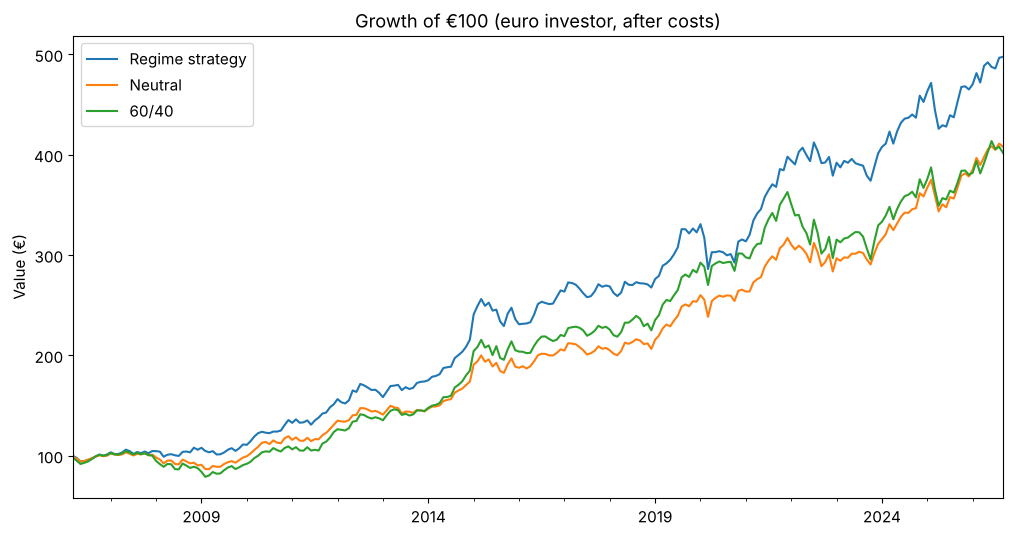

In [6]:
growth.plot(figsize=(12, 6), title="Growth of €100 (euro investor, after costs)")
plt.ylabel("Value (€)")
plt.show()

### Figure 2 for the report: growth of €100 and drawdowns

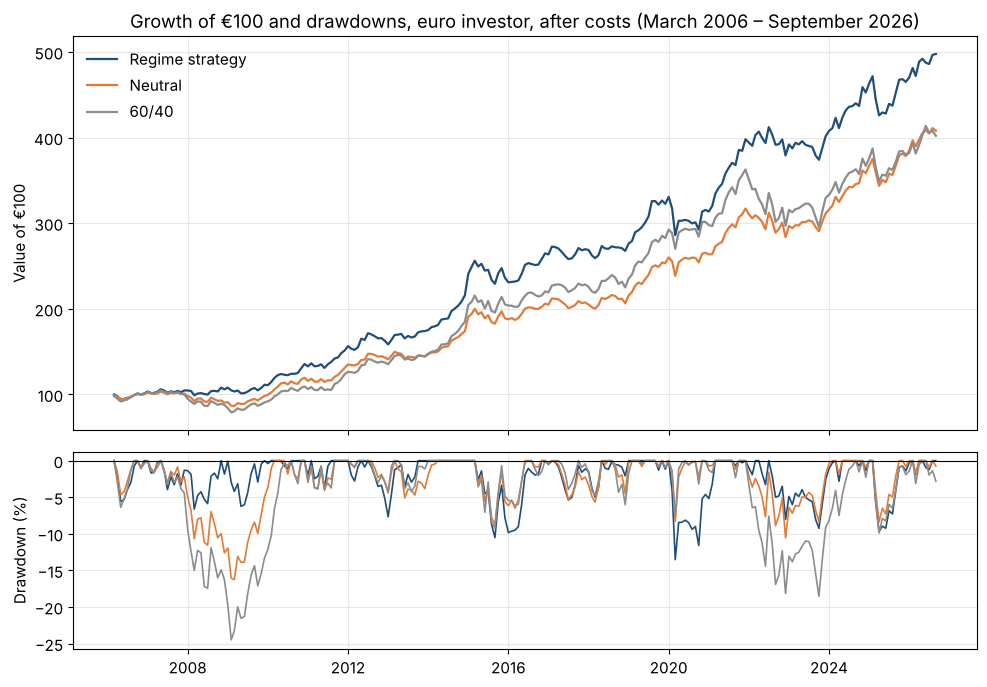

In [7]:
wealth = (1 + results).cumprod()
drawdowns = (wealth / wealth.cummax() - 1) * 100

colours = {"Regime strategy": "#1F4E79", "Neutral": "#E07B39", "60/40": "#8C8C8C"}

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                        gridspec_kw={"height_ratios": [2, 1]})

for name in results.columns:
    ax_top.plot(growth.index, growth[name], color=colours[name], linewidth=1.6, label=name)
    ax_bottom.plot(drawdowns.index, drawdowns[name], color=colours[name], linewidth=1.2)

ax_top.set_ylabel("Value of €100")
ax_top.set_title("Growth of €100 and drawdowns, euro investor, after costs (March 2006 – September 2026)")
ax_top.legend(loc="upper left", frameon=False)
ax_top.grid(alpha=0.3)

ax_bottom.set_ylabel("Drawdown (%)")
ax_bottom.axhline(0, color="black", linewidth=0.8)
ax_bottom.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/fig2_growth_drawdowns.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
print(f"Average turnover per year: {turnover_ea.mean() * 12 * 100:.0f}% of the portfolio")
print(f"Total trading costs over the period: {turnover_ea.sum() * COST * 100:.1f}%")

Average turnover per year: 173% of the portfolio
Total trading costs over the period: 3.6%


### Trading activity

Turnover is about **173% of the portfolio per year**, down from 195% in the first version of the model, because the Economic Sentiment Indicator switches less often than industrial production. The portfolio is still repositioned every few months, since the regime changes whenever either growth or inflation switches.

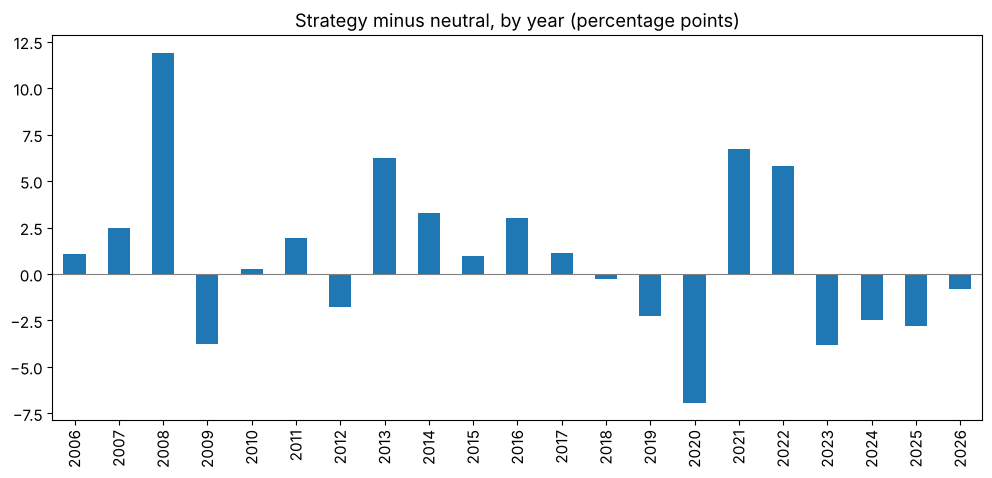

2006     1.1
2007     2.5
2008    11.9
2009    -3.8
2010     0.3
2011     1.9
2012    -1.8
2013     6.3
2014     3.3
2015     0.9
2016     3.0
2017     1.1
2018    -0.3
2019    -2.3
2020    -6.9
2021     6.7
2022     5.8
2023    -3.8
2024    -2.4
2025    -2.8
2026    -0.8
dtype: float64

In [9]:
yearly = (1 + results).groupby(results.index.year).prod() - 1
excess_yearly = (yearly["Regime strategy"] - yearly["Neutral"]) * 100

excess_yearly.plot(kind="bar", figsize=(12, 5), title="Strategy minus neutral, by year (percentage points)")
plt.axhline(0, color="grey", linewidth=0.8)
plt.savefig("../figures/fig3_excess_by_year.png", dpi=200, bbox_inches="tight")
plt.show()

excess_yearly.round(1)

### Year-by-year

The strategy beat the neutral portfolio in **12 of 21 years**. The pattern is clear:

- **Wins when regimes develop gradually:** 2008 (+11.9 points), when sentiment fell well before the crash; 2013 (+6.3), the recovery from the euro crisis; 2021–2022 (+6.7, +5.8), the reopening boom and the switch to Stagflation the month after Russia's invasion of Ukraine.
- **Losses after sudden shocks:** 2020 (−6.9) and 2009 (−3.8). When sentiment collapses together with markets, the model turns defensive just as markets rebound.
- **Losses in directionless periods:** 2023–2026, four negative years in a row. Sentiment has been flat (about 95–97) since 2023, so it crosses its 12-month average back and forth on small moves, and the regime flips on noise.

**2008 alone contributes more than half of the total outperformance.** Without it, the advantage over the neutral portfolio would be roughly 0.4 points a year.

In [10]:
nets = {}
turns = {}

for lag in range(0, 5):
    sig = regimes["ea_regime"].shift(lag, freq="MS")
    net, _, turn = backtest(returns_eur, sig, regime_weights)
    nets[f"Lag {lag}"] = net
    turns[f"Lag {lag}"] = turn

all_nets = pd.DataFrame(nets).dropna()
all_nets["Neutral"] = results["Neutral"]
all_nets = all_nets.dropna()

lag_table = all_nets.apply(performance)
lag_table.loc["Turnover per year (%)"] = pd.Series(
    {name: t.mean() * 12 * 100 for name, t in turns.items()}
)
lag_table.round(2)

,Lag 0,Lag 1,Lag 2,Lag 3,Lag 4,Neutral
Annual return (%),9.04,8.11,8.08,8.36,7.68,7.07
Volatility (%),7.96,8.55,8.28,8.06,8.02,8.02
Return / volatility,1.14,0.95,0.98,1.04,0.96,0.88
Max drawdown (%),-11.06,-13.54,-10.69,-11.93,-10.53,-16.25
Turnover per year (%),170.04,172.96,172.96,169.55,169.55,NaN


## 5. How much does the publication lag cost?

The backtest was repeated with lags of 0 to 4 months, over the same period. Lag 0 is unrealistic: it assumes each month's regime is known instantly.

| | Lag 0 | **Lag 1** | Lag 2 | Lag 3 | Lag 4 | Neutral |
|---|---|---|---|---|---|---|
| Annual return | 9.04% | **8.11%** | 8.08% | 8.36% | 7.68% | 7.07% |
| Return / volatility | 1.14 | **0.95** | 0.98 | 1.04 | 0.96 | 0.88 |
| Max drawdown | −11.1% | **−13.5%** | −10.7% | −11.9% | −10.5% | −16.3% |

With sentiment data, performance is **similar for lags of 1 to 3 months** and somewhat lower at 4 months, but still above the neutral portfolio; differences of a few tenths of a point between lags are within noise. This contrasts with the first version of the model (industrial production), whose edge falls quickly as the lag increases (Section 7).

Likely reasons: the sentiment growth signal persists longer (about 8 months between switches vs 6 for industrial production; the combined regimes, which also switch with inflation, last about 4.7 months), so a delay of a few months matters less; and sentiment is forward-looking, so even a few months old it still says something about the economy, while old output data does not.

## 6. Robustness: two halves of the sample

The sample is split into two decades to check whether the result holds in both.

In [11]:
halves = {
    "2006–2015": slice("2006", "2015"),
    "2016–2026": slice("2016", "2026"),
}

for name, period in halves.items():
    print(name)
    print(results.loc[period].apply(performance).round(2))
    print()

2006–2015
                     Regime strategy  Neutral  60/40
Annual return (%)               9.13     6.68   7.59
Volatility (%)                  8.74     8.33   9.89
Return / volatility             1.05     0.80   0.77
Max drawdown (%)              -10.52   -16.25 -24.50

2016–2026
                     Regime strategy  Neutral  60/40
Annual return (%)               7.18     7.43   6.45
Volatility (%)                  8.40     7.76   9.63
Return / volatility             0.85     0.96   0.67
Max drawdown (%)              -13.54   -10.56 -18.55



| | 2006–2015 | | | 2016–2026 | | |
|---|---|---|---|---|---|---|
| | **Strategy** | Neutral | 60/40 | **Strategy** | Neutral | 60/40 |
| Annual return | **9.13%** | 6.68% | 7.59% | **7.18%** | 7.43% | 6.45% |
| Return / volatility | **1.05** | 0.80 | 0.77 | **0.85** | 0.96 | 0.67 |
| Max drawdown | **−10.5%** | −16.3% | −24.5% | **−13.5%** | −10.6% | −18.6% |

The strategy clearly beat the neutral portfolio in 2006–2015, but **underperformed it in 2016–2026** on return, risk-adjusted return and drawdown. The whole edge comes from the first decade.

The neutral portfolio beat 60/40 on a risk-adjusted basis **in both halves**. Section 8(g) shows that part of this reflects its lower equity share.

## 7. Model versions: industrial production vs sentiment

Two versions of the Euro area model were tested. The growth measure was changed for reasons identified **before** looking at backtest results: industrial production is published late, is noisy, and wrongly classified late 2022 as Overheating.

The two versions also use different lags (industrial production is published about six weeks after the month ends, so its realistic lag is 3 months, against 1 month for the ESI). To separate the **data** from the **delay**, both versions are run at every lag from 0 to 4 months over the same period. The first version's regimes are rebuilt from `macro_data.csv` with the same 12-month rule as in `01_data_pipeline`.

In [12]:
def regimes_from(growth, inflation):
    flags = pd.DataFrame(index=growth.index)
    for name, series in {"growth": growth, "inflation": inflation}.items():
        avg_12m = series.rolling(12).mean()
        flags[name] = (series > avg_12m).where(avg_12m.notna())
    flags = flags.dropna().astype(bool)

    g, i = flags["growth"], flags["inflation"]
    conditions = [g & ~i, g & i, ~g & ~i, ~g & i]
    labels = ["Goldilocks", "Overheating", "Slowdown", "Stagflation"]
    return pd.Series(np.select(conditions, labels, default="Unknown"), index=flags.index)

regime_ip = regimes_from(macro["ea_growth"], macro["ea_inflation"])
regime_ip.loc["2022-06":"2022-12"]

2022-06-01    Stagflation
2022-07-01    Stagflation
2022-08-01    Overheating
2022-09-01    Overheating
2022-10-01    Overheating
2022-11-01    Overheating
2022-12-01    Stagflation
dtype: str

In [13]:
version_nets = {}
version_turns = {}

for lag in range(0, 5):
    for version, regime in {"IP": regime_ip, "ESI": regimes["ea_regime"]}.items():
        net, _, turn = backtest(returns_eur, regime.shift(lag, freq="MS"), regime_weights)
        version_nets[(version, lag)] = net
        version_turns[(version, lag)] = turn

version_nets = pd.DataFrame(version_nets).dropna()
neutral_same = results["Neutral"].loc[version_nets.index]

version_table = pd.DataFrame({
    "IP return (%)": [performance(version_nets[("IP", lag)])["Annual return (%)"] for lag in range(5)],
    "ESI return (%)": [performance(version_nets[("ESI", lag)])["Annual return (%)"] for lag in range(5)],
    "IP ratio": [performance(version_nets[("IP", lag)])["Return / volatility"] for lag in range(5)],
    "ESI ratio": [performance(version_nets[("ESI", lag)])["Return / volatility"] for lag in range(5)],
    "IP turnover (%)": [version_turns[("IP", lag)].mean() * 12 * 100 for lag in range(5)],
}, index=[f"Lag {lag}" for lag in range(5)])

print(f"Common period: {version_nets.index.min():%b %Y} to {version_nets.index.max():%b %Y} ({len(version_nets)} months)")
print(f"Neutral over the same period: {performance(neutral_same)['Annual return (%)']:.2f}%, ratio {performance(neutral_same)['Return / volatility']:.2f}")
version_table.round(2)

Common period: Mar 2006 to Jul 2026 (245 months)
Neutral over the same period: 7.09%, ratio 0.88


,IP return (%),ESI return (%),IP ratio,ESI ratio,IP turnover (%)
Lag 0,9.36,8.99,1.14,1.13,192.49
Lag 1,8.30,8.05,1.01,0.94,194.63
Lag 2,7.99,8.01,0.98,0.96,193.85
Lag 3,7.33,8.33,0.88,1.03,193.85
Lag 4,7.67,7.64,0.90,0.95,193.85


| Lag | IP return | ESI return | IP ratio | ESI ratio |
|---|---|---|---|---|
| 0 | 9.36% | 8.99% | 1.14 | 1.13 |
| 1 | 8.30% | 8.05% | 1.01 | 0.94 |
| 2 | 7.99% | 8.01% | 0.98 | 0.96 |
| 3 | **7.33%** | 8.33% | **0.88** | 1.03 |
| 4 | 7.67% | 7.64% | 0.90 | 0.95 |

*Common period March 2006 – July 2026 (245 months, limited by the latest industrial production data); neutral portfolio 7.09%, ratio 0.88. Realistic versions in bold (IP, lag 3) and in the main results (ESI, lag 1).*

**Result.** At the same lag, the two growth measures perform similarly, and industrial production is slightly better at lags 0 and 1. The difference is in how the information ages: industrial production's edge falls from 2.3 points over neutral at lag 0 to 0.2 points at lag 3, while the ESI's edge stays around 1 point from lag 1 to lag 3. Since industrial production is only published about six weeks after the month ends, it can never be used at lag 1. In practice, the first version earns 7.33% (ratio 0.88, no better than neutral), against 8.05% for the sentiment version.

So the improvement does not come from industrial production being "worse data", but from **timeliness and persistence**: the ESI is available a month after the period it describes, and because it is forward-looking, its information is still useful a few months later. Industrial production describes the past, so by the time it is published its value has largely gone. The first version also trades more (about 194% a year vs 173%).

Every additional version tested increases the risk that one looks good by chance, so both versions are reported.

### Figure 5 for the report: annual return by lag, both versions

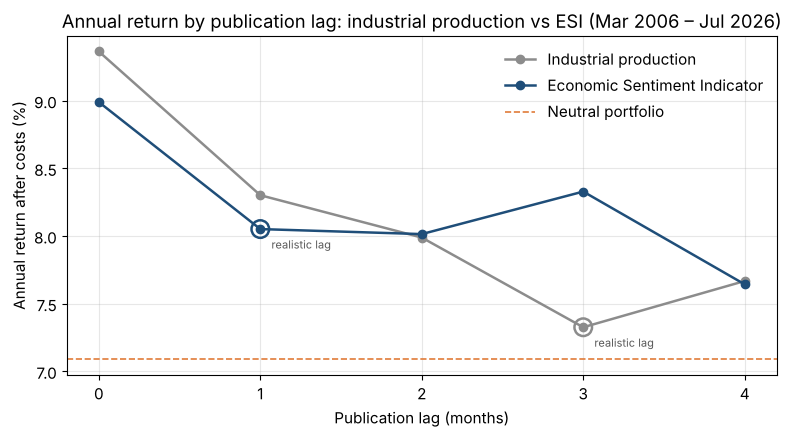

In [14]:
lags = range(5)
neutral_return = performance(neutral_same)["Annual return (%)"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lags, version_table["IP return (%)"], marker="o", color="#8C8C8C", linewidth=1.8, label="Industrial production")
ax.plot(lags, version_table["ESI return (%)"], marker="o", color="#1F4E79", linewidth=1.8, label="Economic Sentiment Indicator")
ax.axhline(neutral_return, color="#E07B39", linestyle="--", linewidth=1.2, label="Neutral portfolio")

ax.scatter([3], [version_table["IP return (%)"].iloc[3]], s=160, facecolors="none", edgecolors="#8C8C8C", linewidths=1.8, zorder=3)
ax.scatter([1], [version_table["ESI return (%)"].iloc[1]], s=160, facecolors="none", edgecolors="#1F4E79", linewidths=1.8, zorder=3)
ax.annotate("realistic lag", (3, version_table["IP return (%)"].iloc[3]), xytext=(8, -14), textcoords="offset points", fontsize=8, color="#595959")
ax.annotate("realistic lag", (1, version_table["ESI return (%)"].iloc[1]), xytext=(8, -14), textcoords="offset points", fontsize=8, color="#595959")

ax.set_xticks(list(lags))
ax.set_xlabel("Publication lag (months)")
ax.set_ylabel("Annual return after costs (%)")
ax.set_title("Annual return by publication lag: industrial production vs ESI (Mar 2006 – Jul 2026)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/fig5_return_by_lag.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Further robustness tests

### 8(a) Trading costs

In [15]:
cost_results = {}

for c in [0, 0.001, 0.002, 0.003]:
    net, _, _ = backtest(returns_eur, signal_ea, regime_weights, cost=c)
    cost_results[f"Cost {c * 100:.1f}%"] = net

cost_table = pd.DataFrame(cost_results)
cost_table["Neutral"] = results["Neutral"]
cost_table = cost_table.dropna()

cost_table.apply(performance).round(2)

,Cost 0.0%,Cost 0.1%,Cost 0.2%,Cost 0.3%,Neutral
Annual return (%),8.29,8.11,7.92,7.74,7.07
Volatility (%),8.55,8.55,8.55,8.55,8.02
Return / volatility,0.97,0.95,0.93,0.90,0.88
Max drawdown (%),-13.47,-13.54,-13.60,-13.66,-16.25


**Result.** Each 0.1% of trading cost reduces annual return by about 0.19 pts, consistent with an annual turnover of 173%. The gross edge over the neutral portfolio (1.2 pts at zero cost) would only disappear at around 0.65% per unit traded, or 0.35–0.4% on a risk-adjusted basis, since the strategy is slightly more volatile (8.55% vs 8.02%). This is several times the 0.02–0.10% typical for liquid ETFs, so transaction costs are not what limits the strategy; statistical significance is.

### 8(b) US investor

In [16]:
strategy_us, _, turnover_us = backtest(returns_usd, signal_us, regime_weights)

results_us = pd.DataFrame({
    "Regime strategy": strategy_us,
    "Neutral": static_portfolio(returns_usd, w_neutral),
    "60/40": static_portfolio(returns_usd, w_6040),
}).dropna()

print("Full period")
print(results_us.apply(performance).round(2))

for name, period in halves.items():
    print()
    print(name)
    print(results_us.loc[period].apply(performance).round(2))

Full period
                     Regime strategy  Neutral  60/40
Annual return (%)               7.15     6.81   6.73
Volatility (%)                  9.02     9.17  10.88
Return / volatility             0.79     0.74   0.62
Max drawdown (%)              -19.10   -25.92 -32.43

2006–2015
                     Regime strategy  Neutral  60/40
Annual return (%)               5.08     5.67   6.57
Volatility (%)                  9.11     9.07  10.42
Return / volatility             0.56     0.62   0.63
Max drawdown (%)              -19.10   -25.92 -32.43

2016–2026
                     Regime strategy  Neutral  60/40
Annual return (%)               9.07     7.87   6.89
Volatility (%)                  8.94     9.28  11.33
Return / volatility             1.01     0.85   0.61
Max drawdown (%)              -15.19   -21.25 -28.19


**Result.** For a US investor (USD returns, US regimes, 2-month lag), the strategy's full-period edge over the neutral portfolio shrinks to 0.3 pts, against 1.0 pts in the euro version, consistent with a slower signal built on weaker growth data (industrial production rather than the ESI). The timing also reverses: the euro version gains 2.4 pts in 2006–2015 and loses 0.3 pts afterwards, while the US version loses 0.6 pts in the first half and gains 1.2 pts in the second. Because the edge appears in different periods depending on region and signal, it should not be treated as a reliable source of return.

The neutral portfolio's drawdown is much deeper for a US investor (−25.9% vs −16.3% in EUR): in 2008 the dollar rose against the euro, which cushions a euro investor's USD assets but adds a currency loss to a US investor's European equities. Diversification still helps in USD: the neutral portfolio has a much smaller drawdown than 60/40 in both halves (−25.9% vs −32.4%, −21.3% vs −28.2%), although on return/volatility the two are level in 2006–2015 (0.62 vs 0.63).

### 8(c) Block bootstrap of the excess return

In [17]:
excess = (results["Regime strategy"] - results["Neutral"]).dropna()

print(f"Months: {len(excess)}")
print(f"Average monthly excess: {excess.mean() * 100:.3f}%")
print(f"Annualised (x12): {excess.mean() * 12 * 100:.2f} pts")
print(f"Autocorrelation (lag 1): {excess.autocorr(lag=1):.2f}")

Months: 247
Average monthly excess: 0.084%
Annualised (x12): 1.01 pts
Autocorrelation (lag 1): 0.13


In [18]:
def block_bootstrap_mean(series, block=12, rng=None):
    values = series.to_numpy()
    n = len(values)
    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=n_blocks)
    sample = np.concatenate([values[s:s + block] for s in starts])[:n]
    return sample.mean()

rng = np.random.default_rng(42)

for i in range(3):
    print(f"{block_bootstrap_mean(excess, rng=rng) * 12 * 100:.2f} pts")

3.15 pts
1.94 pts
0.80 pts


Observed edge: 1.01 pts
95% confidence interval: [-0.94, 2.97] pts
Share of samples with edge <= 0: 14.6%


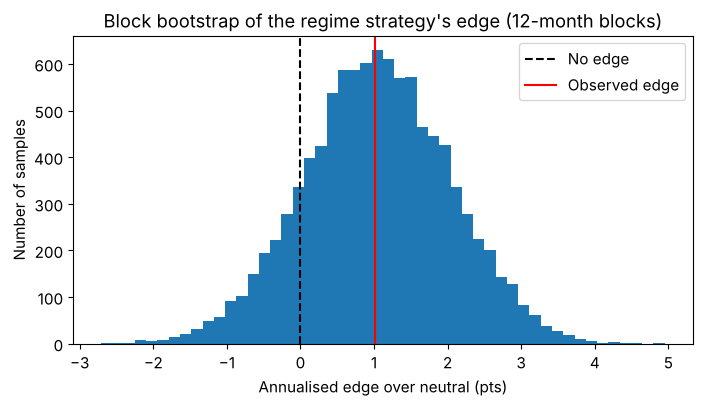

In [19]:
rng = np.random.default_rng(42)

boot = np.array([block_bootstrap_mean(excess, rng=rng) for _ in range(10_000)]) * 12 * 100

ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
share_negative = (boot <= 0).mean()

print(f"Observed edge: {excess.mean() * 12 * 100:.2f} pts")
print(f"95% confidence interval: [{ci_low:.2f}, {ci_high:.2f}] pts")
print(f"Share of samples with edge <= 0: {share_negative:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot, bins=50)
ax.axvline(0, color="black", linestyle="--", label="No edge")
ax.axvline(excess.mean() * 12 * 100, color="red", label="Observed edge")
ax.set_xlabel("Annualised edge over neutral (pts)")
ax.set_ylabel("Number of samples")
ax.set_title("Block bootstrap of the regime strategy's edge (12-month blocks)")
ax.legend()
fig.savefig("../figures/fig4_bootstrap.png", dpi=200, bbox_inches="tight")
plt.show()

**Result.** I tested the monthly return difference between the strategy and the neutral portfolio with a block bootstrap (10,000 samples, 12-month blocks to preserve the persistence created by regimes). The observed edge is 1.01 pts per year (the average monthly difference × 12; the difference between the compound annual returns, 8.11% − 7.07%, is 1.04 pts), but the 95% confidence interval is wide, [−0.94, 2.97] pts, and 14.6% of samples show no outperformance. The edge is therefore not statistically significant in this sample: the data cannot distinguish a small genuine edge from luck. The interval is consistent with the 0.4–0.9% annual outperformance over a static allocation reported by Blitz & van Vliet (2011) from 60 years of data.

### 8(d) Permutation test: shuffling regime episodes

In [20]:
start = excess.index.min() - pd.DateOffset(months=LAG_EA)
signal = signal_ea.dropna().loc[start:]

episode_id = (signal != signal.shift()).cumsum()
episodes = [group.to_numpy() for _, group in signal.groupby(episode_id)]

print(f"Months: {len(signal)}")
print(f"Episodes: {len(episodes)}")
print(signal.value_counts())

Months: 249
Episodes: 53
ea_regime
Overheating    68
Goldilocks     68
Slowdown       68
Stagflation    45
Name: count, dtype: int64


In [21]:
print(signal.index.min(), "to", signal.index.max())
print("Sorted:", signal.index.is_monotonic_increasing)
print("Unique dates:", signal.index.is_unique)
print("Switches:", (signal != signal.shift()).sum() - 1)

2006-02-01 00:00:00 to 2026-10-01 00:00:00
Sorted: True
Unique dates: True
Switches: 52


In [22]:
def shuffle_regimes(signal, episodes, rng):
    order = rng.permutation(len(episodes))
    shuffled = np.concatenate([episodes[i] for i in order])
    return pd.Series(shuffled, index=signal.index, name=signal.name)

rng = np.random.default_rng(42)
test = shuffle_regimes(signal, episodes, rng)

print(test.value_counts())
print()
print(pd.DataFrame({"Real": signal, "Shuffled": test}).head(12))

ea_regime
Slowdown       68
Goldilocks     68
Overheating    68
Stagflation    45
Name: count, dtype: int64

                   Real  Shuffled
2006-02-01  Overheating  Slowdown
2006-03-01  Overheating  Slowdown
2006-04-01   Goldilocks  Slowdown
2006-05-01  Overheating  Slowdown
2006-06-01  Overheating  Slowdown
2006-07-01  Overheating  Slowdown
2006-08-01  Overheating  Slowdown
2006-09-01   Goldilocks  Slowdown
2006-10-01   Goldilocks  Slowdown
2006-11-01   Goldilocks  Slowdown
2006-12-01   Goldilocks  Slowdown
2007-01-01   Goldilocks  Slowdown


Real strategy: 8.11%
Shuffled strategies: mean 6.88%, 95th percentile 8.38%
Share of shuffles the real strategy beats: 90.4%
p-value (shuffles >= real): 0.096


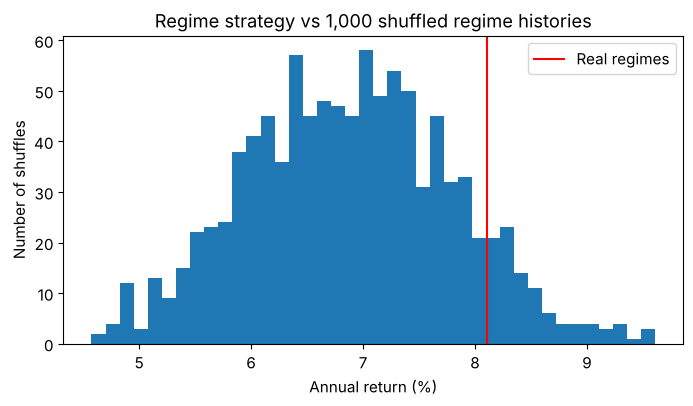

In [23]:
def annual_return(r):
    return ((1 + r).prod() ** (12 / len(r)) - 1) * 100

real = annual_return(results["Regime strategy"].loc[excess.index])

rng = np.random.default_rng(42)
perm = []

for i in range(1_000):
    shuffled_signal = shuffle_regimes(signal, episodes, rng)
    net, _, _ = backtest(returns_eur, shuffled_signal, regime_weights)
    perm.append(annual_return(net.loc[excess.index]))

perm = np.array(perm)

print(f"Real strategy: {real:.2f}%")
print(f"Shuffled strategies: mean {perm.mean():.2f}%, 95th percentile {np.percentile(perm, 95):.2f}%")
print(f"Share of shuffles the real strategy beats: {(perm < real).mean():.1%}")
print(f"p-value (shuffles >= real): {(perm >= real).mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm, bins=40)
ax.axvline(real, color="red", label="Real regimes")
ax.set_xlabel("Annual return (%)")
ax.set_ylabel("Number of shuffles")
ax.set_title("Regime strategy vs 1,000 shuffled regime histories")
ax.legend()
plt.show()

**Result.** To test whether the regimes carry information, I shuffled whole regime episodes 1,000 times (keeping the number of months in each regime and the episode lengths) and reran the backtest with the same tilts and costs. The real strategy (8.11%) beats 90.4% of the shuffled versions (p ≈ 0.10), which is weak evidence that the regimes contain information, significant at the 10% level but not at 5%. The shuffled strategies average 6.88%, roughly the neutral portfolio minus trading costs, so the edge comes from the timing of the tilts rather than from a different average allocation. This is consistent with the bootstrap result (14.6% of samples showing no edge).

Two caveats. Shuffling can merge adjacent episodes of the same regime, so the shuffled strategies trade slightly less and pay lower costs, which makes the test mildly conservative. On the other hand, two growth measures were tested (industrial production and the ESI) and the better one is reported, which makes the p-value somewhat optimistic.

### 8(e) Excluding 2008

In [24]:
no_2008 = results.loc[results.index.year != 2008]

no_2008.apply(performance).round(2)

,Regime strategy,Neutral,60/40
Annual return (%),8.47,8.06,8.09
Volatility (%),8.55,7.86,9.54
Return / volatility,0.99,1.03,0.85
Max drawdown (%),-13.54,-10.56,-18.55


**Result.** Excluding 2008, the strategy's edge over the neutral portfolio falls from 1.04 to 0.41 pts per year, and on a risk-adjusted basis the neutral portfolio is ahead (return/volatility 1.03 vs 0.99). Most of the return edge and all of the risk-adjusted edge therefore come from a single year, when the regimes correctly signalled a defensive position during the financial crisis. The comparison with 60/40 is unaffected: without 2008, the neutral portfolio matches the 60/40 return (8.06% vs 8.09%) with lower volatility (7.86% vs 9.54%) and a smaller drawdown (−10.6% vs −18.6%).

### 8(f) Stock–bond correlation by regime

In [25]:
df = pd.DataFrame({
    "VGK": returns_eur["VGK"],
    "SPY": returns_eur["SPY"],
    "TLT": returns_eur["TLT"],
    "regime": signal,
}).dropna()

corr_table = df.groupby("regime").apply(lambda g: pd.Series({
    "Months": len(g),
    "VGK–TLT": g["VGK"].corr(g["TLT"]),
    "SPY–TLT": g["SPY"].corr(g["TLT"]),
}))

corr_table.loc["All months"] = [len(df), df["VGK"].corr(df["TLT"]), df["SPY"].corr(df["TLT"])]

corr_table.round(2)

,Months,VGK–TLT,SPY–TLT
regime,,,
Goldilocks,68.0,0.03,0.32
Overheating,66.0,-0.34,-0.11
Slowdown,68.0,-0.25,-0.03
Stagflation,45.0,-0.23,0.05
All months,247.0,-0.23,0.01


In [26]:
df_2022 = df.loc["2022"]
print(f"VGK–TLT correlation in 2022: {df_2022['VGK'].corr(df_2022['TLT']):.2f}")
print(df_2022["regime"].value_counts())

VGK–TLT correlation in 2022: 0.34
regime
Stagflation    9
Overheating    3
Name: count, dtype: int64


**Result.** The correlation between European equities (VGK) and long US Treasuries (TLT) in euro terms is negative over the full sample (-0.23) and in every regime except Goldilocks (+0.03), where the hedge matters least. Contrary to the common view, it remains negative on average in Stagflation (-0.23): this regime mixes inflation shocks with growth shocks such as mid-2008, when bonds rallied as a safe haven, and for a euro investor a rising dollar during stress adds to TLT's hedging value. In 2022, however, a true inflation shock that the signal classified mostly as Stagflation (9 of 12 months), the correlation was +0.34 and bonds failed as a hedge. In that year the regime tilts added 5.8 pts over the neutral portfolio, one of their best years after 2008 (+11.9) and 2021 (+6.7). With 45–68 months per regime, differences between the non-Goldilocks regimes are within estimation error.

### 8(g) Neutral vs an equity-matched portfolio

The neutral portfolio holds 45% in equities, 60/40 holds 60%, so its smaller drawdown could simply come from holding less equity. To separate this from the effect of gold and commodities, the neutral portfolio is compared with a portfolio holding the same 45% in equities and its 15% in gold and commodities moved into bonds (TLT +10, LQD +5).

In [27]:
w_equity_bonds = pd.Series({"SPY": 0.25, "VGK": 0.20, "TLT": 0.30, "LQD": 0.15, "SHY": 0.10})

check = pd.DataFrame({
    "Neutral": results["Neutral"],
    "45% equities, 55% bonds": static_portfolio(returns_eur, w_equity_bonds),
    "60/40": results["60/40"],
}).dropna()

for name, period in {"Full period": slice(None), **halves}.items():
    print(name)
    print(check.loc[period].apply(performance).round(2))
    print()

Full period
                     Neutral  45% equities, 55% bonds  60/40
Annual return (%)       7.07                     6.26   6.99
Volatility (%)          8.02                     8.91   9.74
Return / volatility     0.88                     0.70   0.72
Max drawdown (%)      -16.25                   -16.43 -24.50

2006–2015
                     Neutral  45% equities, 55% bonds  60/40
Annual return (%)       6.68                     7.14   7.59
Volatility (%)          8.33                     9.44   9.89
Return / volatility     0.80                     0.76   0.77
Max drawdown (%)      -16.25                   -16.43 -24.50

2016–2026
                     Neutral  45% equities, 55% bonds  60/40
Annual return (%)       7.43                     5.47   6.45
Volatility (%)          7.76                     8.42   9.63
Return / volatility     0.96                     0.65   0.67
Max drawdown (%)      -10.56                   -15.62 -18.55



**Result.** With the same 45% in equities, a portfolio of equities and bonds only had almost the same worst loss as the neutral portfolio (−16.4% vs −16.3%), but a clearly lower return relative to risk (0.70 vs 0.88). So most of the neutral portfolio's smaller drawdown compared with 60/40 comes from holding less equity and shorter-duration bonds, not from gold and commodities. What gold and commodities added was a better return for the risk taken, and almost all of it came after 2016 (0.96 vs 0.65, largely 2022, when bonds and equities fell together); in 2006–2015 the two were close (0.80 vs 0.76).

## 9. Conclusions

1. **The regimes contain some information, but the edge is small and not statistically significant.** After realistic publication lags and costs, the strategy earned about 1 point a year more than the neutral portfolio. The block bootstrap gives a 95% interval of [−0.9, 3.0] points, and the permutation test p ≈ 0.10, which is optimistic because two growth measures were tested.
2. **The edge is period-dependent.** It comes almost entirely from 2006–2015, mainly 2008; without 2008 the neutral portfolio is ahead on a risk-adjusted basis. For a US investor the timing reverses (the edge appears after 2016 instead). The model adds value in gradually developing downturns and loses after sudden shocks (2020) and in directionless markets (2023–2026).
3. **Timeliness and persistence of the signal matter.** Industrial production works when fresh but is published too late to be used fresh, and its information fades quickly with delay. The Economic Sentiment Indicator is available sooner and its information survives a delay of several months.
4. **Trading costs are not the constraint.** The edge would only disappear at costs several times higher than those of liquid ETFs.
5. **Portfolio construction is the robust result.** The static neutral portfolio had lower volatility and a much smaller worst loss than 60/40 in every test (both halves, both investors, with and without 2008). Section 8(g) shows that most of the smaller loss comes from its lower equity share and shorter bond duration, while gold and commodities improved its return relative to risk, mainly after 2016. Bonds did not hedge equities in 2022, when both fell together.

## 10. Limitations and future work

**Limitations**
- **One sample, one crisis.** The sample starts in 2006 (the youngest ETF), so it excludes the 2000–2002 bear market, and much of the edge depends on 2008.
- **Revised data.** The backtest uses today's revised data, not the figures available at the time; the latest Euro area inflation is a flash estimate, released about one day after month-end.
- **Sudden shocks.** Monthly economic data reacts after markets in sudden crises (2020), so the strategy turns defensive just as markets rebound.
- **"Cash" is US dollar cash.** For a euro investor, SHY is a dollar position, so tilts into it are partly currency bets.
- **Simplifications.** Return / volatility ignores the risk-free rate, and benchmarks are rebalanced without costs.
- **Multiple testing.** Two growth measures and several lags were examined; the reported p-value does not adjust for this.

**Future work**
- Real-time (vintage) data, e.g. ALFRED for the US and the ECB's real-time database for the Euro area.
- Regime-based weights estimated with a walk-forward method and shrunk towards the neutral portfolio, instead of fixed tilts.
- Similarity-based regimes (Mulliner, Harvey, Xia, Fang & Van Hemert, 2026) as an alternative to the four quadrants.
- A threshold rule to reduce switching in flat periods was considered but not tested, to avoid adding another variant.